<a href="https://colab.research.google.com/github/KatKolesnyk/python-portfolio/blob/main/Global_Sales_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Sales Data Analysis: Data Cleaning, Exploration & Business Insights

**Project overview:**
This project analyzes multi-year sales data from a company operating in both online and offline retail channels across the global market. The dataset consists of three related tables — order-level sales events, product categories, and country/region reference data.

**Objectives:**
- Clean and validate the dataset (missing values, duplicates, anomalies, data type consistency)
- Merge the three source tables into a single analytical dataset
- Calculate key business metrics (revenue, cost, profit, order volume, market coverage)
- Analyze sales performance across product categories, geography, and sales channels
- Investigate shipping time patterns and their relationship with profitability
- Identify sales trends over time and potential seasonality by day of the week

**Tools & libraries:** Python, pandas, NumPy, Matplotlib, Seaborn

**Dataset:** `events.csv` (order-level sales records), `products.csv` (product categories), `countries.csv` (country and region reference data)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/Pandas

# Uploading dataset
data_countries = pd.read_csv("countries.csv")
data_events = pd.read_csv("events.csv")
data_products = pd.read_csv("products.csv")
display(data_countries.head())
display(data_events.head())
display(data_products.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Pandas


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


# **1. Data overview**

## Countries table:
*249 rows; there are gaps in alpha-2 (248/249) and in region, sub-region (248/249)*

* name - country name
* alpha-2 - country code (2 letters)
* alpha-3 - country code (3 letters)
* region - region name
* sub-region - sub-region name
## Events table:
*1330 rows; gaps in Country Code (1248/1330) and Units Sold (1328/1330). The Order Date and Ship Date columns are of type object, not date — they will need to be converted to datetime during the cleanup phase, and you should also change the data type in the Order ID and Product ID columns*

* Order ID - order code
* Order Date - order creation date
* Ship Date - order shipment date
* Order Priority - order priority
* Country Code - country code (3 letters)
* Product ID - product code
* Sales Channel - sales channels (online/offline)
* Units Sold - number of units sold
* Unit Price - price per unit
* Unit Cost - cost per unit
## Products table:
*12 rows, no gaps, you should change the data type in the id column during the cleanup phase*
* id - product code
* item_type - product name

*The Countries table and the Products table should be joined to the Events table using the following columns: countries.alpha-3 = events.Country Code, products.id = events.Product ID*

In [3]:
# General information about tables (data types, number of rows and columns, unknown values)
data_countries.info()
print()
data_events.info()
print()
data_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price   

# **2. Data cleaning**

In [4]:
# Finding unknown values ​​for a countries table
print(data_countries.isna().sum())
print()
print(data_countries.isna().sum()/ data_countries.shape[0] * 100)

name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64

name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64


In [5]:
data_countries.loc[data_countries["name"] == "Antarctica", ["region", "sub-region"]] = "Antarctica" # Filling in unknown column values region and sub-region
data_countries.loc[data_countries["name"] == "Namibia", "alpha-2"] = "NA" # Filling in unknown column value alpha-2

In the Countries table, the omissions have two different reasons. The absence of region and sub-region for Antarctica is logical, since the continent is not included in any region in the UN classification, so the value is filled in as "Antarctica". The absence of alpha-2 for Namibia is a technical parsing error: the country code "NA" was automatically recognized as indicating missing data, so the value is manually restored as "NA".

Since the percentage of omissions is negligible (0.4%) and the reasons are understood, it is inappropriate to delete the rows - a point correction preserves the completeness of the data.

In [6]:
# Finding unknown values ​​for a Events table
print(data_events.isna().sum())
print()
print(data_events.isna().sum()/ data_events.shape[0] * 100)

Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64

Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


In [7]:
data_events["Country Code"] = data_events["Country Code"].fillna("Unknown")
data_events = data_events.dropna(subset=["Units Sold"])

In the Events table, gaps were found in two columns. Country Code contains 82 gaps (6.17%) without the ability to restore the values ​​point-by-point, so they are filled as "Unknown" — such rows should be excluded from the analysis by country, but they remain useful for general sales metrics. Units Sold has only 2 gaps (0.15%), so these rows are deleted — such a small number does not affect the statistics, and deleting is easier and safer than filling.

In [8]:
# Type conversion in columns
data_events["Order Date"] = pd.to_datetime(data_events["Order Date"], format="%m/%d/%Y")
data_events["Ship Date"] = pd.to_datetime(data_events["Ship Date"], format="%m/%d/%Y")
data_events["Order ID"] = data_events["Order ID"].astype(str)
data_events["Product ID"] = data_events["Product ID"].astype(str)
data_products["id"] = data_products["id"].astype(str)
data_events.info()
data_products.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   object        
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   object        
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   float64       
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), object(5)
memory usage: 114.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 no

In [9]:
# Finding explicit duplicates (full string match):
print(f"Countries: {data_countries.duplicated().sum()}")
print(f"Events: {data_events.duplicated().sum()}")
print(f"Products: {data_products.duplicated().sum()}")

# Conversion to the same register
data_countries["alpha-3"] = data_countries["alpha-3"].str.upper()
data_countries["alpha-2"] = data_countries["alpha-2"].str.upper()
data_events["Country Code"] = data_events["Country Code"].str.upper()
data_events["Order Priority"] = data_events["Order Priority"].str.upper()
data_countries["name"] = data_countries["name"].str.title()
data_countries["region"] = data_countries["region"].str.title()
data_countries["sub-region"] = data_countries["sub-region"].str.title()
data_events["Sales Channel"] = data_events["Sales Channel"].str.title()
data_products["item_type"] = data_products["item_type"].str.title()


# Select only text columns
text_columns_c = data_countries.select_dtypes(include="object").columns
text_columns_e = data_events.select_dtypes(include="object").columns
text_columns_p = data_products.select_dtypes(include="object").columns

# Remove extra spaces at the beginning/end and double spaces inside for all text columns
for col_c in text_columns_c:
    data_countries[col_c] = data_countries[col_c].str.strip().str.replace(r'\s+', ' ', regex=True)

for col_p in text_columns_p:
    data_products[col_p] = data_products[col_p].str.strip().str.replace(r'\s+', ' ', regex=True)

for col_e in text_columns_e:
    data_events[col_e] = data_events[col_e].str.strip().str.replace(r'\s+', ' ', regex=True)

# Removing similarities between Cyrillic/Latin letters
def normalize_text(text):
    if pd.isna(text):
        return text
    cyrillic_to_latin = {
        'а': 'a', 'б': 'b', 'в': 'v', 'г': 'h', 'д': 'd', 'е': 'e', 'є': 'ie', 'ж': 'zh',
        'з': 'z', 'и': 'y', 'і': 'i', 'ї': 'i', 'й': 'i', 'к': 'k', 'л': 'l', 'м': 'm',
        'н': 'n', 'о': 'o', 'п': 'p', 'р': 'r', 'с': 's', 'т': 't', 'у': 'u', 'ф': 'f',
        'х': 'kh', 'ц': 'ts', 'ч': 'ch', 'ш': 'sh', 'щ': 'shch', 'ь': '', 'ю': 'iu', 'я': 'ia'
    }
    for cyr, lat in cyrillic_to_latin.items():
        text = text.replace(cyr, lat)
    return text

# Apply to all text columns of each table separately
check_col_countries = data_countries.copy()
check_col_events = data_events.copy()
check_col_products = data_products.copy()

for col_c in text_columns_c:
    check_col_countries[col_c] = data_countries[col_c].apply(normalize_text)

for col_e in text_columns_e:
  check_col_events[col_e] = data_events[col_e].apply(normalize_text)

for col_p in text_columns_p:
    check_col_products[col_p] = data_products[col_p].apply(normalize_text)

Countries: 0
Events: 0
Products: 0


In [10]:
# Finding duplicates after normalization
print(f"Countries: {check_col_countries.duplicated().sum()}")
print(f"Events: {check_col_events.duplicated().sum()}")
print(f"Products: {check_col_products.duplicated().sum()}")

Countries: 0
Events: 0
Products: 0


## Examining data for anomalies:

In [11]:
# Price, cost, and quantity cannot be negative or zero.
anomalies = data_events[(data_events["Unit Price"] <= 0) | (data_events["Unit Cost"] <= 0) | (data_events["Units Sold"] <= 0)]
if len(anomalies) > 0:
    print(f"Anomalies found: {len(anomalies)}")
    print(anomalies)
else:
    print("No anomalies")

# Ship Date cannot be before Order Date
data_events["Order Date"] = pd.to_datetime(data_events["Order Date"])
data_events["Ship Date"] = pd.to_datetime(data_events["Ship Date"])
anomalies_dates = data_events[data_events["Ship Date"] < data_events["Order Date"]]
if len(anomalies_dates) > 0:
    print(f"Anomalies found: {len(anomalies_dates)}")
    print(anomalies_dates)
else:
    print("No anomalies")

# Outliers in numeric columns via describe()
print(data_events[["Units Sold", "Unit Price", "Unit Cost"]].describe())

# Categorical columns - checking for unexpected values
print(data_events['Sales Channel'].unique())
print(data_events['Order Priority'].unique())
print(data_countries['region'].unique())

No anomalies
No anomalies
        Units Sold   Unit Price    Unit Cost
count  1328.000000  1328.000000  1328.000000
mean   4952.201807   264.913245   187.211521
std    2905.198996   217.386320   176.187801
min       2.000000     9.330000     6.920000
25%    2356.750000    81.730000    35.840000
50%    4962.000000   154.060000    97.440000
75%    7459.500000   437.200000   263.330000
max    9999.000000   668.270000   524.960000
['Online' 'Offline']
['M' 'C' 'L' 'H']
['Asia' 'Europe' 'Africa' 'Oceania' 'Americas' 'Antarctica']


# **3. Data analysis and visualization**

In [12]:
# Joining tables
data_countries = data_countries.rename(columns={"alpha-3": "Country Code"})
data_products = data_products.rename(columns={"id": "Product ID"})
data_full = pd.merge(data_events, data_countries, on="Country Code", how="left")
data_full = pd.merge(data_full, data_products, on="Product ID", how="left")
data_full.columns = data_full.columns.str.title().str.replace(' ', '_')

## Key metrics of the company's performance:

In [13]:
# Key metrics of the company's performance
print("Total Volumes:")
print(f"Total Orders: {len(data_full)}")
print(f"Total Units Sold: {data_full["Units_Sold"].sum():,.0f}")
print(f"Total Countries Covered: {data_full['Name'].nunique()}")
print(f"Total Product Categories: {data_products["item_type"].nunique()}")
print(f"Data Time Range: {data_full["Order_Date"].min().strftime('%Y-%m-%d')} - {data_full["Order_Date"].max().strftime('%Y-%m-%d')}")

print("\nFinancial Metrics:")

data_full["Total_Revenue"] = data_full["Units_Sold"] * data_full["Unit_Price"]
data_full["Total_Cost"] = data_full["Units_Sold"] * data_full["Unit_Cost"]
data_full["Total_Profit"] = data_full["Total_Revenue"] - data_full["Total_Cost"]

print(f"Total Revenue: {data_full["Total_Revenue"].sum():,.2f}")
print(f"Total Cost: {data_full["Total_Cost"].sum():,.2f}")
print(f"Total Profit: {data_full["Total_Profit"].sum():,.2f}")
print(f"Average Profit Per Order: {data_full['Total_Profit'].mean():,.2f}")
print(f"Margin: {data_full["Total_Profit"].sum() / data_full["Total_Revenue"].sum() * 100:.2f}%")

print("\nAverages:")
print(f"Average receipt: {data_full["Total_Revenue"].median():.2f}")
print(f"Average number of units in an order: {data_full["Units_Sold"].median()}")

data_full["Shipping_Days"] = (data_full["Order_Date"] - data_full["Ship_Date"]).dt.days.abs()

print(f"Average shipping interval: {data_full["Shipping_Days"].mean():.1f} days")

print("\nDistribution by channels and priorities:")

channel_orders = data_full["Sales_Channel"].value_counts(normalize=True) * 100
channel_revenue = data_full.groupby("Sales_Channel")["Total_Revenue"].sum()
channel_revenue_share = channel_revenue / channel_revenue.sum() * 100

print("\tShare by number of orders:")
print(channel_orders.round(1))
print("\n\tShare by revenue:")
print(channel_revenue_share.round(1))

priority_distribution = data_full["Order_Priority"].value_counts(normalize=True) * 100
print("\n\tDistribution of orders by Order Priority:")
print(priority_distribution.round(1))

print("\nTop indicators:")
profit_by_category = data_full.groupby("Item_Type")["Total_Profit"].sum().sort_values(ascending=False)
print(f"Most profitable category: {profit_by_category.index[0]}")

revenue_by_country = data_full.groupby("Name")["Total_Revenue"].sum().sort_values(ascending=False)
print(f"Top Country by Revenue: {revenue_by_country.index[0]}")

revenue_by_region = data_full.groupby("Region")["Total_Revenue"].sum().sort_values(ascending=False)
print(f"Top Region by Revenue: {revenue_by_region.index[0]}")

units_by_product = data_full.groupby("Item_Type")["Units_Sold"].sum().sort_values(ascending=False)
print(f"Top Product by Sales: {units_by_product.index[0]}")

Total Volumes:
Total Orders: 1328
Total Units Sold: 6,576,524
Total Countries Covered: 45
Total Product Categories: 12
Data Time Range: 2010-01-01 - 2017-07-23

Financial Metrics:
Total Revenue: 1,702,129,408.21
Total Cost: 1,200,694,949.21
Total Profit: 501,434,459.00
Average Profit Per Order: 377,586.19
Margin: 29.46%

Averages:
Average receipt: 761304.88
Average number of units in an order: 4962.0
Average shipping interval: 24.8 days

Distribution by channels and priorities:
	Share by number of orders:
Sales_Channel
Offline    50.1
Online     49.9
Name: proportion, dtype: float64

	Share by revenue:
Sales_Channel
Offline    51.2
Online     48.8
Name: Total_Revenue, dtype: float64

	Distribution of orders by Order Priority:
Order_Priority
M    26.6
H    25.2
L    25.2
C    23.0
Name: proportion, dtype: float64

Top indicators:
Most profitable category: Cosmetics
Top Country by Revenue: Czech Republic
Top Region by Revenue: Europe
Top Product by Sales: Office Supplies


Between January 2010 and July 2017, the company processed 1,328 orders, selling over 6.5 million units. Total revenue reached 1.70 billion USD, with 1.20 billion USD in costs, leaving a net profit of 501 million USD — a 29.46% margin, a solidly healthy figure for retail. Average profit per order is approximately 377,587 USD, and the average order value is 761,305 USD, pointing to predominantly large-volume orders (averaging ~4,962 units each). Sales channels are nearly balanced: Offline accounts for 50.1% of orders and 51.2% of revenue, Online for 49.9% and 48.8% respectively, meaning the business is not critically dependent on either channel. Order priorities are evenly distributed (23-27% per level), with no single urgency type dominating. The most profitable category is Cosmetics, the top-selling product by volume is Office Supplies, and the largest revenue contributors are the Czech Republic among countries and Europe among regions — consistent with the company's overall geographic sales structure.

## Sales analysis:

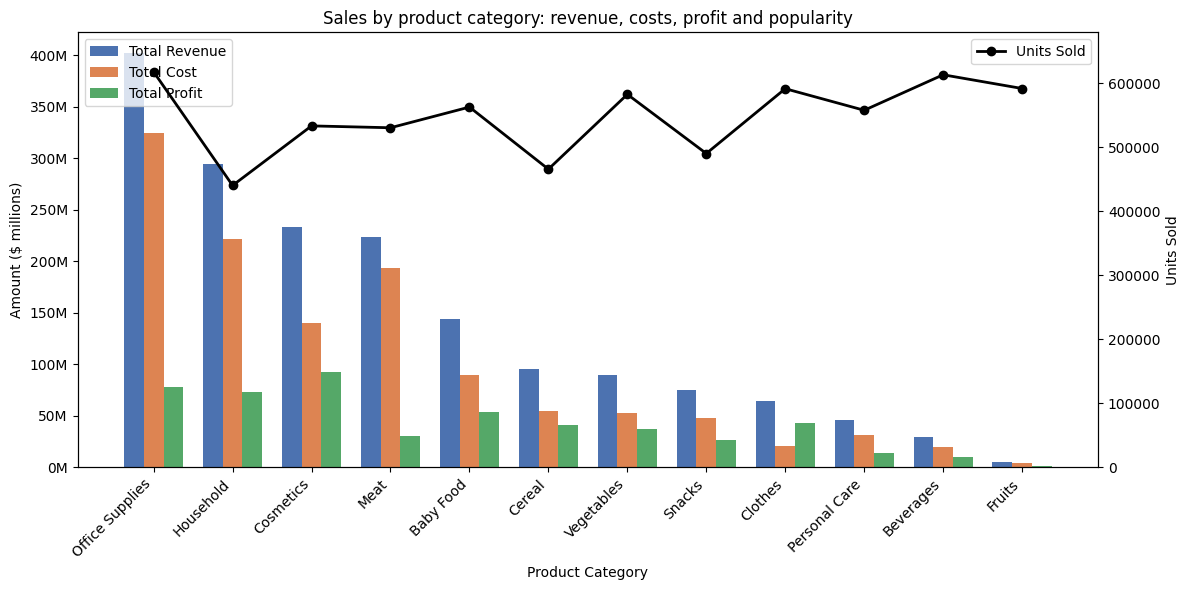

In [14]:
# Aggregation by category
category_summary = data_full.groupby("Item_Type").agg(
    Revenue=("Total_Revenue", "sum"),
    Cost=("Total_Cost", "sum"),
    Profit=("Total_Profit", "sum"),
    Units_Sold=("Units_Sold", "sum")
).sort_values("Revenue", ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(len(category_summary))
width = 0.25

# Columns: income, expenses, profit
ax1.bar(x - width, category_summary["Revenue"], width, label="Total Revenue", color="#4C72B0")
ax1.bar(x, category_summary["Cost"], width, label="Total Cost", color="#DD8452")
ax1.bar(x + width, category_summary["Profit"], width, label="Total Profit", color="#55A868")

ax1.set_xlabel("Product Category")
ax1.set_ylabel("Amount ($ millions)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax1.set_xticks(x)
ax1.set_xticklabels(category_summary.index, rotation=45, ha="right")
ax1.legend(loc="upper left")

# Second axis: popularity (number of units sold)
ax2 = ax1.twinx()
ax2.plot(x, category_summary["Units_Sold"], color="black", marker="o", linewidth=2, label="Units Sold")
ax2.set_ylabel("Units Sold")
ax2.set_ylim(0, category_summary["Units_Sold"].max() * 1.1)
ax2.legend(loc="upper right")

plt.title("Sales by product category: revenue, costs, profit and popularity")
plt.tight_layout()
plt.show()

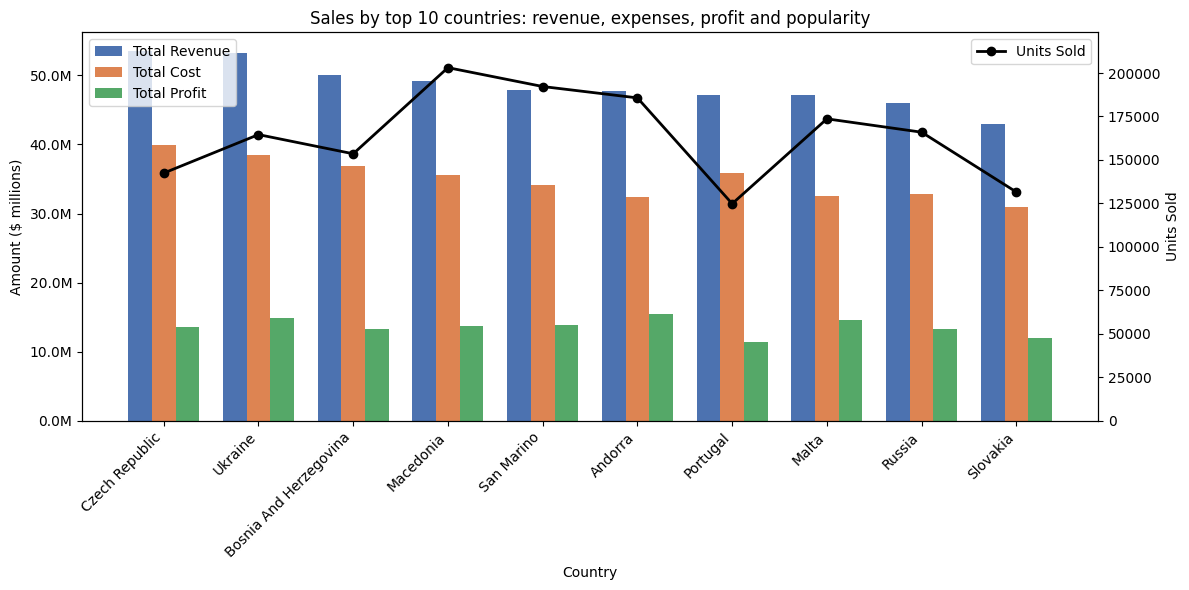

In [15]:
# Aggregation by country
countries_summary = data_full.groupby("Name").agg(
    Revenue = ("Total_Revenue", "sum"),
    Cost = ("Total_Cost", "sum"),
    Profit = ("Total_Profit", "sum"),
    Units_Sold = ("Units_Sold", "sum")
).sort_values("Revenue", ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(10)
width = 0.25

# Columns: income, expenses, profit
ax1.bar(x - width, countries_summary["Revenue"], width, label="Total Revenue", color="#4C72B0")
ax1.bar(x, countries_summary["Cost"], width, label="Total Cost", color="#DD8452")
ax1.bar(x + width, countries_summary["Profit"], width, label="Total Profit", color="#55A868")

ax1.set_xlabel("Country")
ax1.set_ylabel("Amount ($ millions)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax1.set_xticks(x)
ax1.set_xticklabels(countries_summary.index, rotation=45, ha="right")
ax1.legend(loc="upper left")

# Second axis: popularity (number of units sold)
ax2 = ax1.twinx()
ax2.plot(x, countries_summary["Units_Sold"], color="black", marker="o", linewidth=2, label="Units Sold")
ax2.set_ylabel("Units Sold")
ax2.set_ylim(0, countries_summary["Units_Sold"].max() * 1.1)
ax2.legend(loc="upper right")

plt.title("Sales by top 10 countries: revenue, expenses, profit and popularity")
plt.tight_layout()
plt.show()

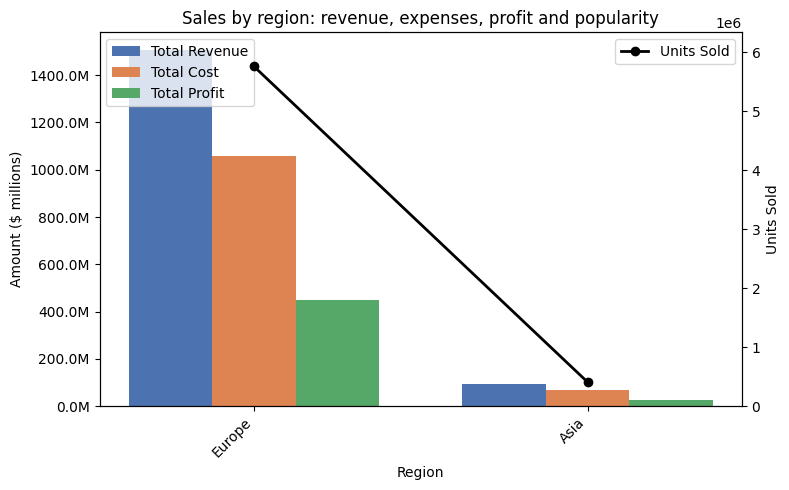

In [16]:
# Aggregation by region
regions_summary = data_full.groupby("Region").agg(
    Revenue = ("Total_Revenue", "sum"),
    Cost = ("Total_Cost", "sum"),
    Profit = ("Total_Profit", "sum"),
    Units_Sold = ("Units_Sold", "sum")
).sort_values("Revenue", ascending=False)

fig, ax1 = plt.subplots(figsize=(8, 5))

x = np.arange(len(regions_summary))
width = 0.25

# Columns: income, expenses, profit
ax1.bar(x - width, regions_summary["Revenue"], width, label="Total Revenue", color="#4C72B0")
ax1.bar(x, regions_summary["Cost"], width, label="Total Cost", color="#DD8452")
ax1.bar(x + width, regions_summary["Profit"], width, label="Total Profit", color="#55A868")

ax1.set_xlabel("Region")
ax1.set_ylabel("Amount ($ millions)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax1.set_xticks(x)
ax1.set_xticklabels(regions_summary.index, rotation=45, ha="right")
ax1.legend(loc="upper left")

# Second axis: popularity (number of units sold)
ax2 = ax1.twinx()
ax2.plot(x, regions_summary["Units_Sold"], color="black", marker="o", linewidth=2, label="Units Sold")
ax2.set_ylabel("Units Sold")
ax2.set_ylim(0, regions_summary["Units_Sold"].max() * 1.1)
ax2.legend(loc="upper right")

plt.title("Sales by region: revenue, expenses, profit and popularity")
plt.tight_layout()
plt.show()

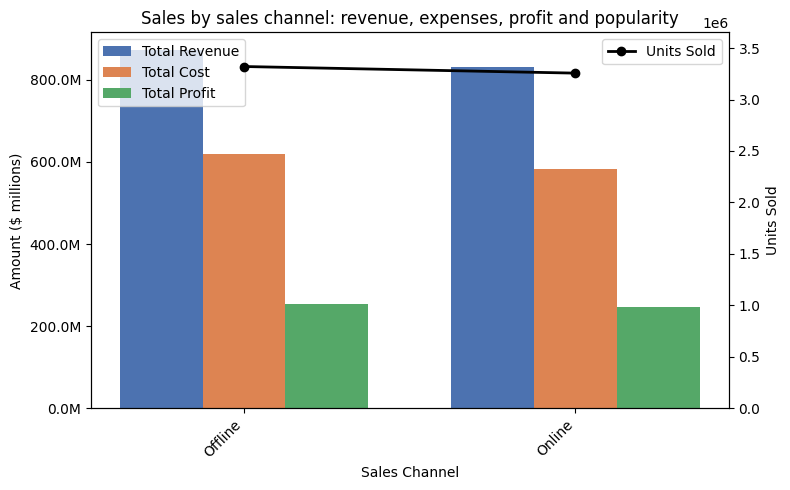

In [17]:
# Aggregation by channel
channels_summary = data_full.groupby("Sales_Channel").agg(
    Revenue = ("Total_Revenue", "sum"),
    Cost = ("Total_Cost", "sum"),
    Profit = ("Total_Profit", "sum"),
    Units_Sold = ("Units_Sold", "sum")
).sort_values("Revenue", ascending=False)

fig, ax1 = plt.subplots(figsize=(8, 5))

x = np.arange(len(channels_summary))
width = 0.25

# Columns: income, expenses, profit
ax1.bar(x - width, channels_summary["Revenue"], width, label="Total Revenue", color="#4C72B0")
ax1.bar(x, channels_summary["Cost"], width, label="Total Cost", color="#DD8452")
ax1.bar(x + width, channels_summary["Profit"], width, label="Total Profit", color="#55A868")

ax1.set_xlabel("Sales Channel")
ax1.set_ylabel("Amount ($ millions)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax1.set_xticks(x)
ax1.set_xticklabels(channels_summary.index, rotation=45, ha="right")
ax1.legend(loc="upper left")

# Second axis: popularity (number of units sold)
ax2 = ax1.twinx()
ax2.plot(x, channels_summary["Units_Sold"], color="black", marker="o", linewidth=2, label="Units Sold")
ax2.set_ylabel("Units Sold")
ax2.set_ylim(0, channels_summary["Units_Sold"].max() * 1.1)
ax2.legend(loc="upper right")

plt.title("Sales by sales channel: revenue, expenses, profit and popularity")
plt.tight_layout()
plt.show()

The sales breakdown by product category, geography, and channel reveals several consistent patterns. Among product categories, Cosmetics generates the highest profit, while Office Supplies leads in units sold — a classic divergence between a "popular but low-margin" and a "less voluminous but highly profitable" product line, showing that the top-selling category isn't necessarily the most profitable one. Geographically, profit is distributed relatively evenly across the top-10 countries despite substantial differences in revenue volume, indicating that the company maintains stable margins regardless of a given market's scale. At the regional level, Europe dominates Asia by a wide margin in revenue, reflecting a customer base concentrated primarily on the European market. Sales channels, on the other hand, show a well-balanced picture: Offline and Online are nearly identical in order count (50.1% vs 49.9%), revenue share (51.2% vs 48.8%), and units sold — the company performs equally well in both retail formats, without dependence on a single channel.

## Analysis of the time interval between order and shipment:

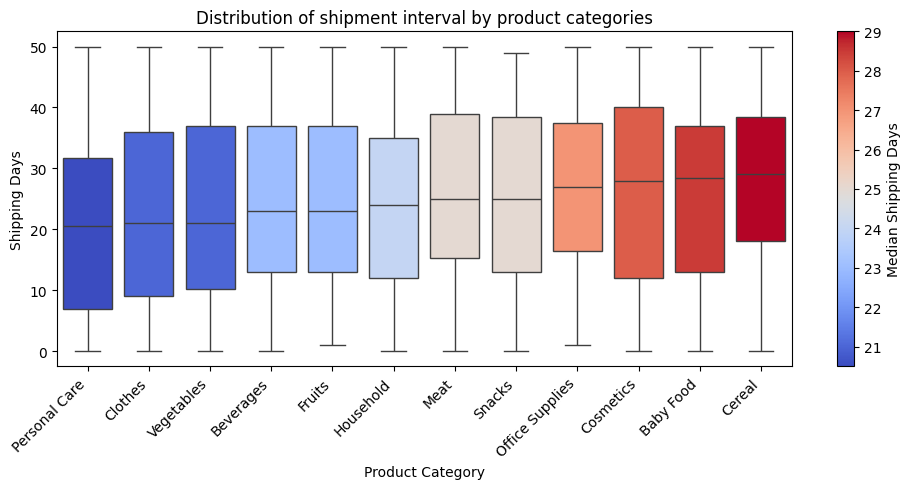

In [18]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Sort Categories by median Shipping_Days
order = data_full.groupby("Item_Type")["Shipping_Days"].median().sort_values().index
medians = data_full.groupby("Item_Type")["Shipping_Days"].median().loc[order]

norm = mcolors.Normalize(vmin=medians.min(), vmax=medians.max())
colors = [cm.coolwarm(norm(val)) for val in medians]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=data_full, x="Item_Type", y="Shipping_Days", order=order, ax=ax)

for patch, color in zip(ax.patches, colors):
    patch.set_facecolor(color)

ax.set_xlabel("Product Category")
ax.set_ylabel("Shipping Days")
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of shipment interval by product categories")

sm = cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Median Shipping Days")

plt.tight_layout()
plt.show()

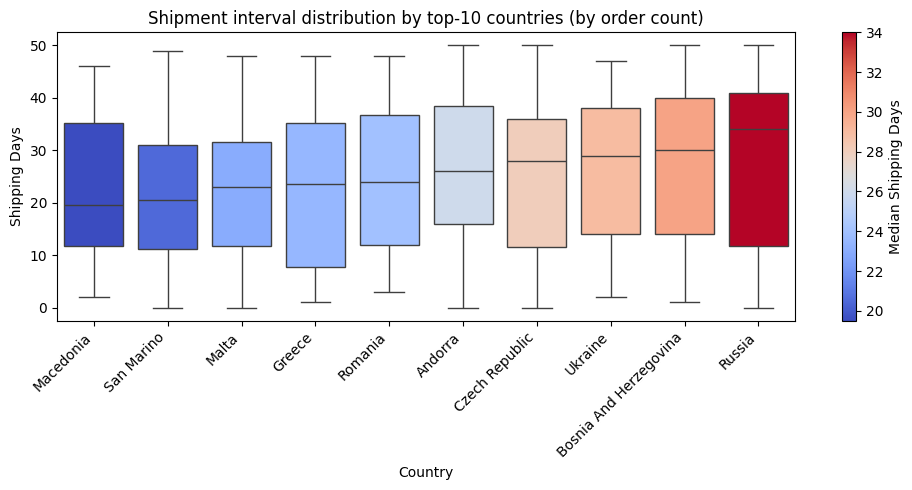

In [19]:
# Sort Countries by median Shipping_Days
top_countries = data_full["Name"].value_counts().head(10).index
data_top = data_full[data_full["Name"].isin(top_countries)]

order = data_top.groupby("Name")["Shipping_Days"].median().sort_values().index
medians = data_top.groupby("Name")["Shipping_Days"].median().loc[order]

norm = mcolors.Normalize(vmin=medians.min(), vmax=medians.max())
colors = [cm.coolwarm(norm(val)) for val in medians]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=data_top, x="Name", y="Shipping_Days", order=order, ax=ax)

for patch, color in zip(ax.patches, colors):
    patch.set_facecolor(color)

ax.set_xlabel("Country")
ax.set_ylabel("Shipping Days")
plt.xticks(rotation=45, ha="right")
plt.title("Shipment interval distribution by top-10 countries (by order count)")

sm = cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Median Shipping Days")

plt.tight_layout()
plt.show()

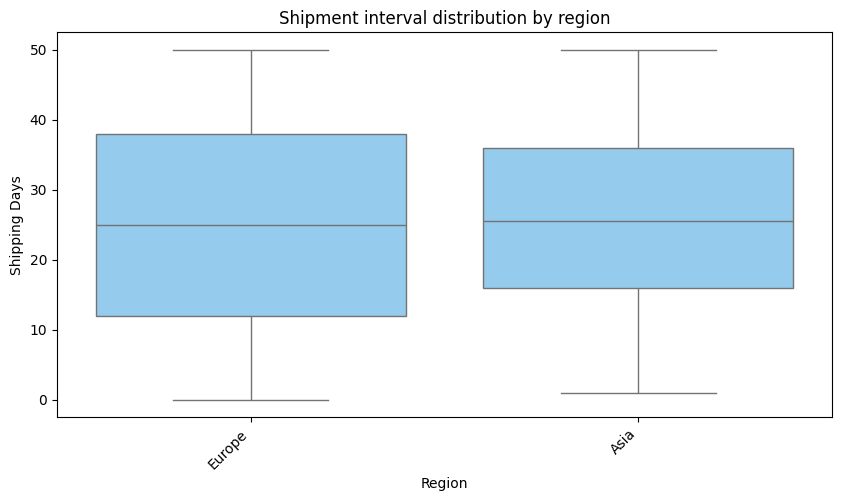

In [20]:
# Sort Regions by median Shipping_Days
order = data_full.groupby("Region")["Shipping_Days"].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=data_full, x="Region", y="Shipping_Days", color="lightskyblue", order=order, ax=ax)

ax.set_xlabel("Region")
ax.set_ylabel("Shipping Days")
plt.xticks(rotation=45, ha="right")
plt.title("Shipment interval distribution by region")
plt.show()

The analysis of the time interval between order and shipment revealed no significant differences across product categories, countries, or regions — median values in every breakdown fall within approximately 19-30 days, with no clear leader or outlier. This suggests that the company's order processing and shipping workflow is standardized and independent of product type, sales geography, or market — logistics perform equally predictably regardless of what is being shipped or where. The spread of values (boxplot width) varies somewhat more than the medians themselves, indicating uneven process stability in certain categories or countries, but without a systematic pattern tied to any specific factor. At the regional level, Europe and Asia are also nearly identical in median shipping time (a difference of less than one day), further confirming the absence of any geographic dependency in shipping speed.

## The Relationship Between Profit and the Time Required to Ship Goods:

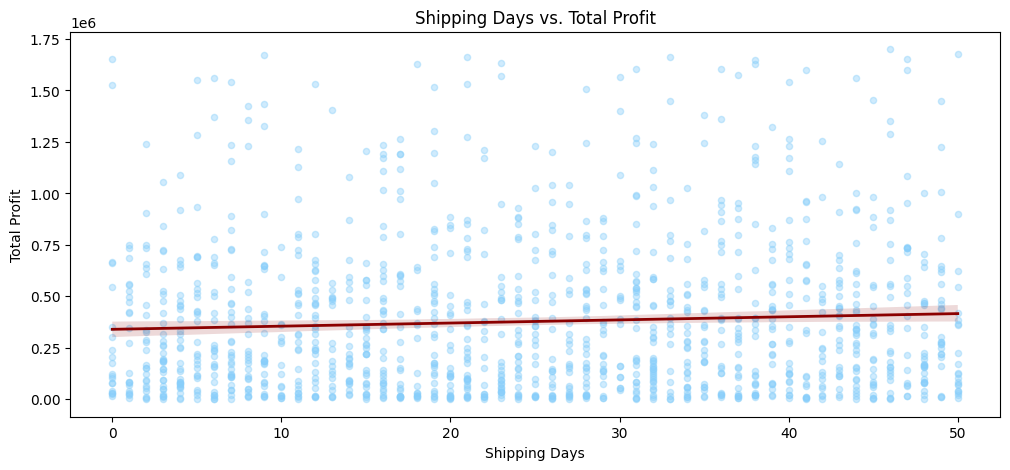

In [21]:
data_full["Shipping_Bin"] = pd.cut(data_full["Shipping_Days"], bins=[0,5,10,15,20,25,30,35,40,45,50], include_lowest=True)

fig, ax = plt.subplots(figsize=(12, 5))

sns.regplot(data=data_full, x="Shipping_Days", y="Total_Profit", scatter_kws={"color": "lightskyblue", "alpha": 0.4, "s": 20}, line_kws={"color": "darkred", "linewidth": 2})

plt.title("Shipping Days vs. Total Profit")
plt.xlabel("Shipping Days")
plt.ylabel("Total Profit")
plt.show()

In [22]:
# Calculating the correlation coefficient between indicators
correlation = data_full["Shipping_Days"].corr(data_full["Total_Profit"])
print(f"Correlation between Shipping Days and Total Profit: {correlation:.3f}")

Correlation between Shipping Days and Total Profit: 0.060


The correlation between shipping time and profit is only 0.06 — indicating essentially no relationship between the two. The trend line on the chart is nearly flat: average profit stays around 0.35–0.4 regardless of whether an order is shipped in 1 day or 50 days. The spread of points remains similarly wide across the entire Shipping Days range, confirming that shipping speed does not affect order profitability — these two metrics are driven by different, independent factors (likely unit price, product category, quantity sold, etc.).

## Sales Trends (Over Time):

In [23]:
# Extract the year from Order_Date to enable yearly aggregation
data_full["Order_Year"] = data_full["Order_Date"].dt.year

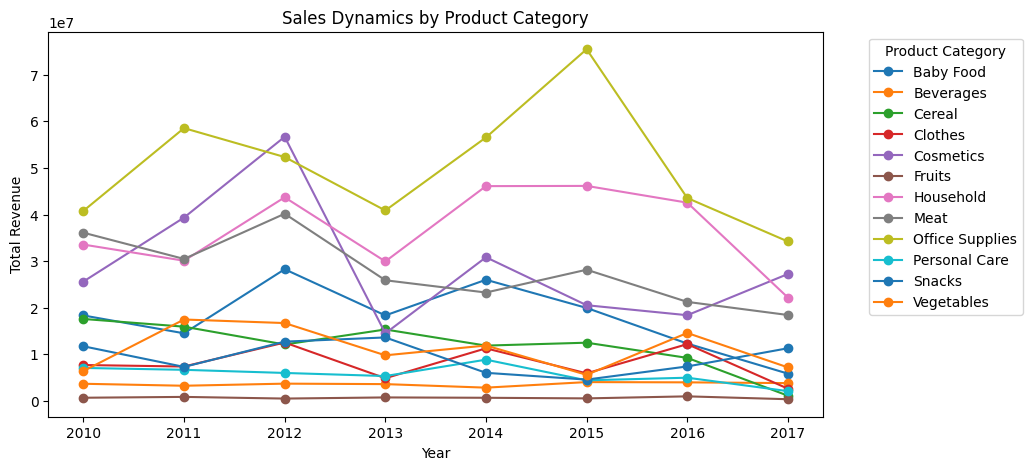

In [24]:
# Visualization of sales dynamics (over time) by product category
yearly_category = data_full.groupby(["Order_Year", "Item_Type"])["Total_Revenue"].sum().reset_index()

plt.figure(figsize=(10, 5))
for category in yearly_category["Item_Type"].unique():
    subset = yearly_category[yearly_category["Item_Type"] == category]
    plt.plot(subset["Order_Year"], subset["Total_Revenue"], marker="o", label=category)

plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.title("Sales Dynamics by Product Category")
plt.legend(title="Product Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

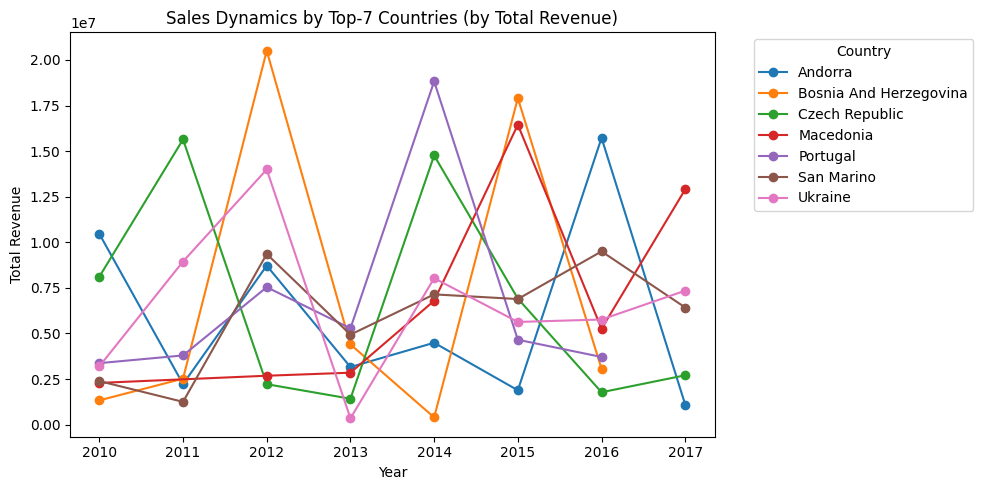

In [25]:
# Visualization of sales dynamics (over time) by countries
top_countries = data_full.groupby("Name")["Total_Revenue"].sum().sort_values(ascending=False).head(7).index
data_top_countries = data_full[data_full["Name"].isin(top_countries)]

yearly_countries = data_top_countries.groupby(["Order_Year", "Name"])["Total_Revenue"].sum().reset_index()

plt.figure(figsize=(10, 5))
for country in yearly_countries["Name"].unique():
    subset = yearly_countries[yearly_countries["Name"] == country]
    plt.plot(subset["Order_Year"], subset["Total_Revenue"], marker="o", label=country)

plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.title("Sales Dynamics by Top-7 Countries (by Total Revenue)")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

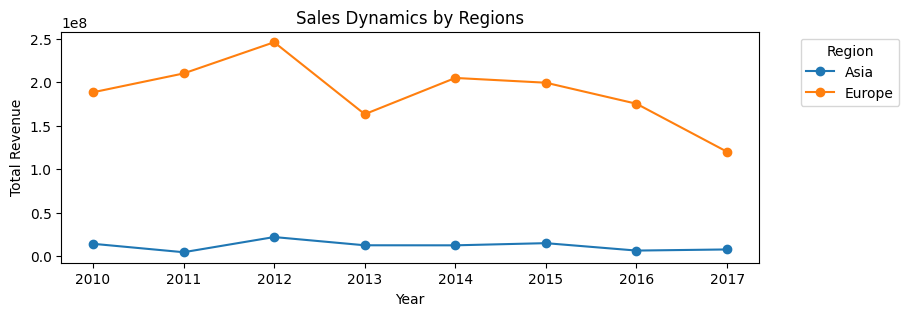

In [26]:
# Visualization of sales dynamics (over time) by regions
yearly_region = data_full.groupby(["Order_Year", "Region"])["Total_Revenue"].sum().reset_index()

plt.figure(figsize=(9, 3))
for region in yearly_region["Region"].unique():
    subset = yearly_region[yearly_region["Region"] == region]
    plt.plot(subset["Order_Year"], subset["Total_Revenue"], marker="o", label=region)

plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.title("Sales Dynamics by Regions")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

The sales dynamics analysis for 2010-2017 shows no stable trends at the level of individual product categories or countries — all metrics display sharp year-to-year fluctuations (e.g., Office Supplies jumps from 4 to 7.5 and back to 3.4; Bosnia and Herzegovina swings from 1.3 to 20.5 and back to 0.5), which is more indicative of statistical noise from a small number of orders per category/country per year than genuine business trends. The only statistically reliable pattern emerges at the regional level, where data aggregation is largest: Europe consistently dominates Asia (10-15x higher revenue) and shows a clear declining trend over the last three years of the period — falling from a peak of ~2.0 in 2015 to ~1.2 in 2017. This is the most important signal for the business: sales in the company's key region are shrinking, while Asia remains a stable but minor market with no significant dynamics.

## Analysis of product sales by day of the week:

In [27]:
# Extract the day of the week from Order_Date to enable day of the week aggregation
data_full["Order_Day"] = data_full["Order_Date"].dt.day_name()

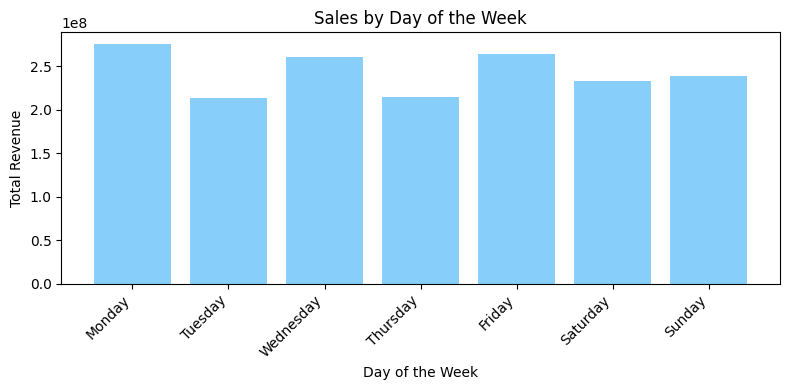

In [28]:
grouped_by_day = data_full.groupby("Order_Day")["Total_Revenue"].sum()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
grouped_by_day = grouped_by_day.reindex(weekday_order)

plt.figure(figsize=(8, 4))
plt.bar(grouped_by_day.index, grouped_by_day, color="lightskyblue")

plt.xlabel("Day of the Week")
plt.ylabel("Total Revenue")
plt.title("Sales by Day of the Week")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

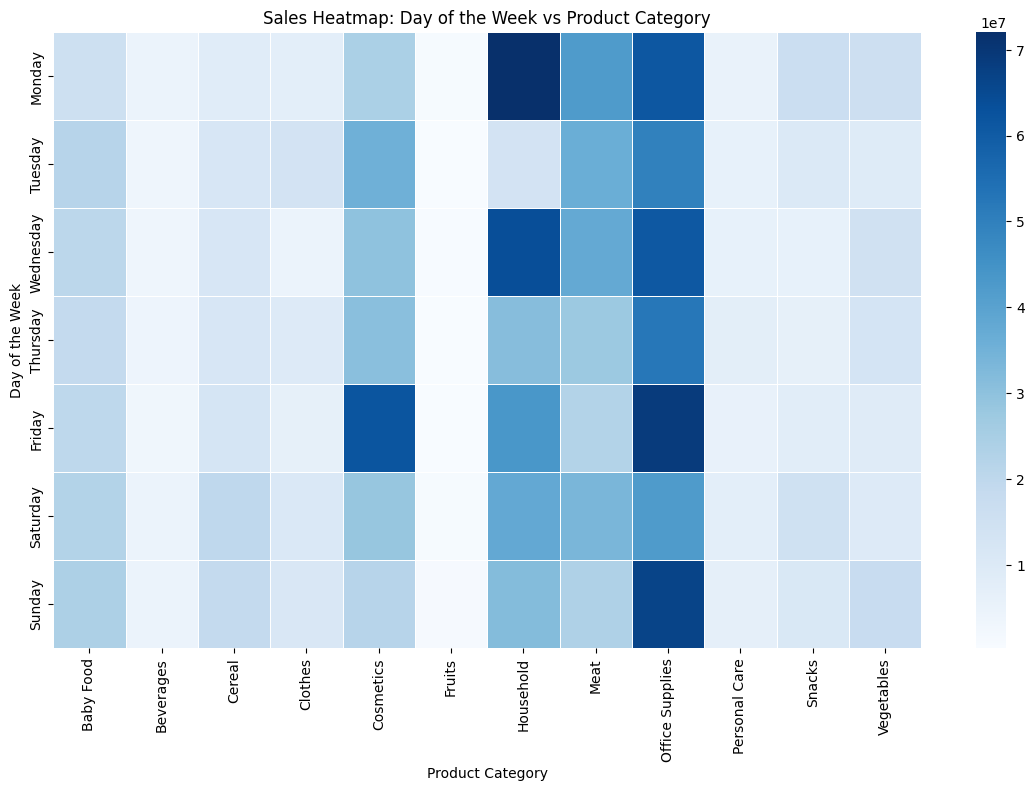

In [29]:
sales_by_day_category = data_full.groupby(["Order_Day", "Item_Type"])["Total_Revenue"].sum().unstack()
sales_by_day_category = sales_by_day_category.reindex(weekday_order)

plt.figure(figsize=(14, 8))
sns.heatmap(sales_by_day_category, cmap="Blues", annot=False, linewidths=0.5)
plt.xlabel("Product Category")
plt.ylabel("Day of the Week")
plt.title("Sales Heatmap: Day of the Week vs Product Category")
plt.show()

The heatmap shows that revenue by product category is uneven — Household, Meat, and Office Supplies have the highest sales values on most days, while Fruits, Personal Care, and Beverages remain consistently low regardless of the day of the week. Regarding seasonality: Household shows pronounced peaks specifically on Monday and Wednesday, with noticeably lower values on other days — this may indicate a pattern in order placement for this category. Cosmetics shows a clear peak on Friday, markedly higher than other days. Office Supplies remains consistently high across nearly every day, without a strong tie to any specific day. Overall, only a few categories (Household, Cosmetics) show signs of day-of-week seasonality, while most other categories sell fairly evenly throughout the week without clear cyclicality.

## Order Priority vs. Profit and Shipping Speed

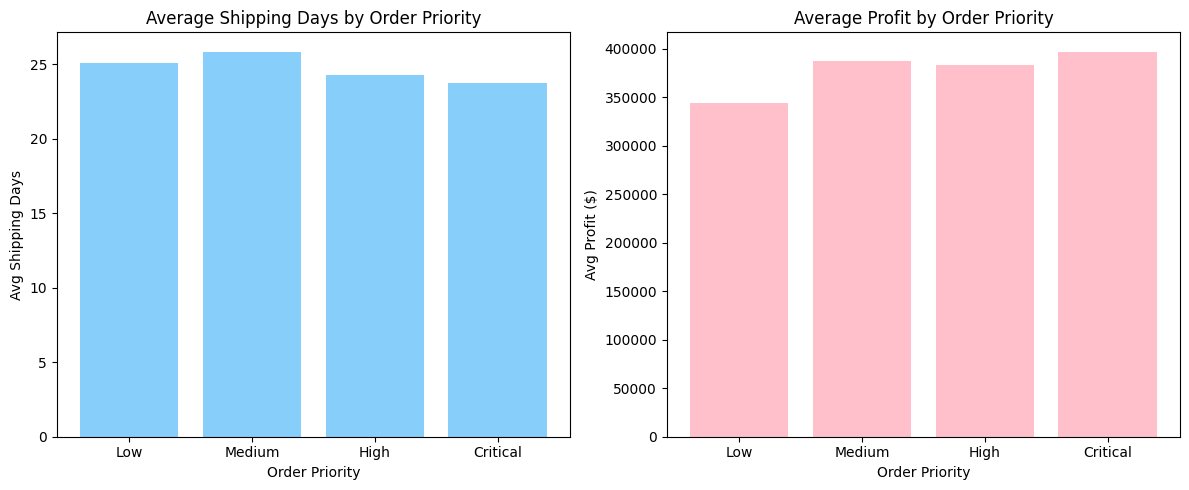

                Avg_Shipping_Days  Avg_Profit  Order_Count
Order_Priority                                            
Low                         25.10   343937.39          334
Medium                      25.86   387509.69          353
High                        24.32   383001.17          335
Critical                    23.72   396938.10          306


In [38]:
# Does a higher order priority actually lead to faster shipping or higher profit?
priority_order = ["L", "M", "H", "C"]
priority_labels = {"L": "Low", "M": "Medium", "H": "High", "C": "Critical"}

priority_summary = data_full.groupby("Order_Priority").agg(
    Avg_Shipping_Days=("Shipping_Days", "mean"),
    Avg_Profit=("Total_Profit", "mean"),
    Order_Count=("Total_Profit", "count")
).reindex(priority_order)
priority_summary.index = priority_summary.index.map(priority_labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(priority_summary.index, priority_summary["Avg_Shipping_Days"], color="lightskyblue")
ax1.set_title("Average Shipping Days by Order Priority")
ax1.set_xlabel("Order Priority")
ax1.set_ylabel("Avg Shipping Days")

ax2.bar(priority_summary.index, priority_summary["Avg_Profit"], color="pink")
ax2.set_title("Average Profit by Order Priority")
ax2.set_xlabel("Order Priority")
ax2.set_ylabel("Avg Profit ($)")

plt.tight_layout()
plt.show()

print(priority_summary.round(2))

Contrary to what the "priority" label might suggest, order priority shows no meaningful effect on
either shipping speed or profitability. Average shipping time ranges narrowly from 23.7 days
(Critical) to 25.9 days (Medium) — a spread of about 2 days with no monotonic pattern: Medium-priority
orders actually ship slightly slower than Low-priority ones. Average profit per order also shows no
clear priority-driven trend (Low: 343,937 USD vs. Critical: 396,938 USD, but Medium and High fall in between
without ordering by priority level). This confirms, at a categorical level, what the earlier
correlation analysis already suggested: shipping and profit are driven by factors unrelated to the
priority flag, and the priority label appears to be largely informational rather than operationally
enforced.

## Profit Margin (%) by Category — Beyond Absolute Profit

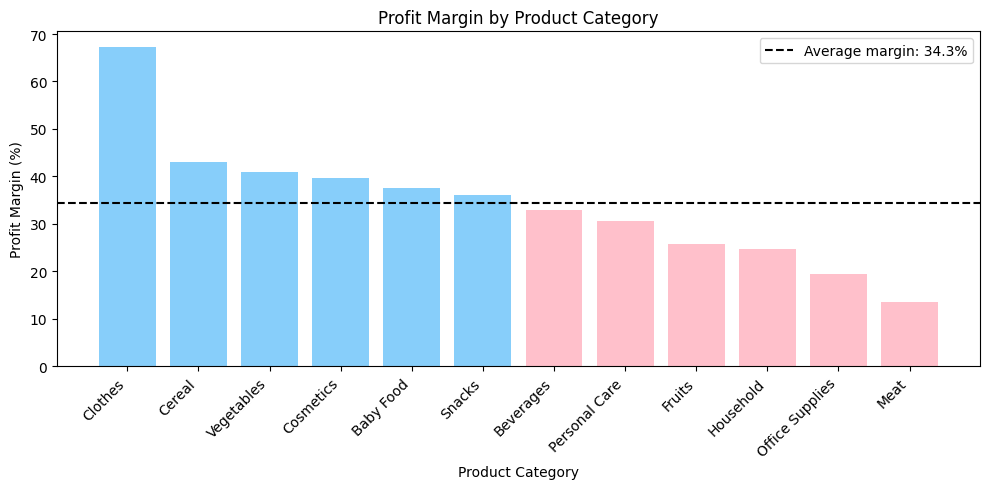

                      Revenue       Profit  Margin_Percent
Item_Type                                                 
Clothes          6.462655e+07  43431314.40           67.20
Cereal           9.579140e+07  41255034.15           43.07
Vegetables       8.974673e+07  36776002.72           40.98
Cosmetics        2.331548e+08  92723306.17           39.77
Baby Food        1.436476e+08  53940997.16           37.55
Snacks           7.478861e+07  27027422.40           36.14
Beverages        2.909316e+07   9601662.78           33.00
Personal Care    4.557902e+07  13975410.68           30.66
Fruits           5.520300e+06   1425929.52           25.83
Household        2.942052e+08  72962466.77           24.80
Office Supplies  4.022140e+08  77977176.25           19.39
Meat             2.237620e+08  30337736.00           13.56


In [34]:
# Absolute profit favors high-volume categories. Margin % reveals which
# categories are actually the most efficient, regardless of scale.
category_margin = data_full.groupby("Item_Type").agg(
    Revenue=("Total_Revenue", "sum"),
    Profit=("Total_Profit", "sum")
)
category_margin["Margin_Percent"] = category_margin["Profit"] / category_margin["Revenue"] * 100
category_margin = category_margin.sort_values("Margin_Percent", ascending=False)

plt.figure(figsize=(10, 5))
colors = ["lightskyblue" if x >= category_margin["Margin_Percent"].median() else "pink"
          for x in category_margin["Margin_Percent"]]
plt.bar(category_margin.index, category_margin["Margin_Percent"], color=colors)
plt.axhline(category_margin["Margin_Percent"].mean(), color="black", linestyle="--",
            label=f"Average margin: {category_margin['Margin_Percent'].mean():.1f}%")
plt.xlabel("Product Category")
plt.ylabel("Profit Margin (%)")
plt.title("Profit Margin by Product Category")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

print(category_margin.round(2))

Ranking categories by margin rather than absolute profit tells a noticeably different story. Clothes
has by far the highest margin at 67.2% — nearly double the company average — despite generating only
modest absolute profit (43.4M USD), since its revenue base is comparatively small. Cosmetics, the leader
in absolute profit from the earlier analysis, ranks only 4th by margin (39.8%). Meanwhile, Office
Supplies — the top-selling category by volume — has one of the lowest margins at 19.4%, and Meat sits
at the bottom (13.6%) despite substantial revenue (224M USD). This reinforces the earlier "popular vs.
profitable" divergence and adds a sharper business signal: Clothes may be an under-scaled,
high-efficiency category worth expanding, while high-volume categories like Office Supplies and Meat
are comparatively inefficient use of sales effort per dollar of revenue.

## Correlation Between Key Numeric Metrics

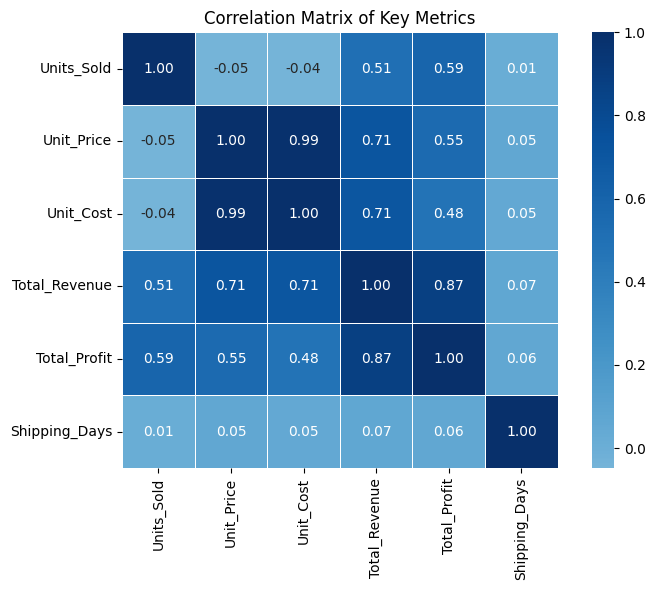

In [36]:
# A quick way to spot any strong (or surprisingly weak) relationships
# between core business metrics in one view.
numeric_cols = ["Units_Sold", "Unit_Price", "Unit_Cost", "Total_Revenue",
                 "Total_Profit", "Shipping_Days"]
corr_matrix = data_full[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Matrix of Key Metrics")
plt.tight_layout()
plt.show()

The correlation matrix confirms several expected relationships and one important negative finding.
Unit_Price and Unit_Cost are almost perfectly correlated (0.99), indicating cost scales tightly with
price across the product range. Total_Revenue correlates strongly with Total_Profit (0.87), as
expected. Most notably, Shipping_Days shows essentially zero correlation with every other metric
(0.01–0.07) — including Total_Profit (0.06) and Total_Revenue (0.07). This numerically confirms, across
the entire dataset in a single view, what the earlier shipping-time analysis and the priority
breakdown both pointed to separately: shipping speed is fully decoupled from the company's financial
performance.

# **Business conclusions**
The analysis shows the company to be in a financially healthy position: between 2010 and 2017, it processed 1,328 orders generating 1.70 billion USD in revenue at a nearly 30% margin — a consistently strong figure for retail. The business model is well diversified, with no critical dependency on either sales channel (Offline and Online are split almost evenly), and margins remain stable regardless of a given market's scale. At the same time, the analysis also revealed a concentration risk: the company operates predominantly in the European market (Europe generates an order of magnitude more revenue than Asia), and it is precisely in this key region that a concerning signal emerges — a sustained decline in sales over the last three years of the period (from a 2015 peak through 2017), while the Asian market remains stable but secondary and largely undeveloped.
The company's operational processes proved to be well standardized: shipping speed (averaging ~25 days) does not depend on product category, country, or region, nor does it affect order profitability (the correlation between shipping time and profit is statistically insignificant, at 0.06) — indicating that logistics operate consistently and predictably, and are not a bottleneck for the business. The product mix analysis revealed a classic divergence between popularity and profitability: Office Supplies leads in sales volume, but Cosmetics generates the highest profit — suggesting potential for reassessing pricing strategy or marketing focus toward higher-margin categories. Signs of day-of-week seasonality were found only in select categories (Household, Cosmetics), while most of the product range sells evenly throughout the week, requiring no special logistics or promotional adjustments tied to specific days.
The main business recommendation: the company should investigate the causes of declining sales in Europe over the recent years of the period — this is the most important and statistically reliable signal from the entire analysis, as the remaining fluctuations observed at the individual category or country level are more likely explained by small sample sizes than by genuine business trends.
A margin-based view of the product mix adds an important nuance to the earlier profitability findings:
Clothes, not Cosmetics, has the highest profit margin (67.2%) despite modest absolute revenue,
suggesting an under-leveraged, high-efficiency category worth expanding — while high-volume categories
like Office Supplies and Meat convert revenue into profit far less efficiently. Additionally, order
priority and shipping speed were confirmed to have no meaningful relationship with profitability at
any level of analysis (correlation ≤ 0.07 across all financial metrics), reinforcing that the
company's logistics operate independently of — and do not constrain — its financial results.